In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deap-datasetraw-data/s04.bdf
/kaggle/input/deap-datasetraw-data/s32.bdf
/kaggle/input/deap-datasetraw-data/s23.bdf
/kaggle/input/deap-datasetraw-data/s26.bdf
/kaggle/input/deap-datasetraw-data/s20.bdf
/kaggle/input/deap-datasetraw-data/s27.bdf
/kaggle/input/deap-datasetraw-data/s03.bdf
/kaggle/input/deap-datasetraw-data/s06.bdf
/kaggle/input/deap-datasetraw-data/s18.bdf
/kaggle/input/deap-datasetraw-data/s07.bdf
/kaggle/input/deap-datasetraw-data/s19.bdf
/kaggle/input/deap-datasetraw-data/s16.bdf
/kaggle/input/deap-datasetraw-data/s15.bdf
/kaggle/input/deap-datasetraw-data/s17.bdf
/kaggle/input/deap-datasetraw-data/s08.bdf
/kaggle/input/deap-datasetraw-data/s09.bdf
/kaggle/input/deap-datasetraw-data/s11.bdf
/kaggle/input/deap-datasetraw-data/s01.bdf
/kaggle/input/deap-datasetraw-data/s29.bdf
/kaggle/input/deap-datasetraw-data/s24.bdf
/kaggle/input/deap-datasetraw-data/s05.bdf
/kaggle/input/deap-datasetraw-data/s28.bdf
/kaggle/input/deap-datasetraw-data/s22.bdf
/kaggle/inp

In [2]:
import os

DATA_DIR = '/kaggle/input/deap-datasetraw-data'
print(os.listdir(DATA_DIR))


['s04.bdf', 's32.bdf', 's23.bdf', 's26.bdf', 's20.bdf', 's27.bdf', 's03.bdf', 's06.bdf', 's18.bdf', 's07.bdf', 's19.bdf', 's16.bdf', 's15.bdf', 's17.bdf', 's08.bdf', 's09.bdf', 's11.bdf', 's01.bdf', 's29.bdf', 's24.bdf', 's05.bdf', 's28.bdf', 's22.bdf', 's14.bdf', 's30.bdf', 's25.bdf', 's02.bdf', 's12.bdf', 's21.bdf', 's13.bdf', 's10.bdf', 's31.bdf']


In [3]:
!pip install mne


Extracting EDF parameters from /kaggle/input/deap-datasetraw-data/s01.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1980927  =      0.000 ...  3868.998 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 47 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 104.0 Hz
 meas_date: 2010-07-01 10:00:16 UTC
 nchan: 48
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: s01>
>
['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Using matplotlib as 2D backend.


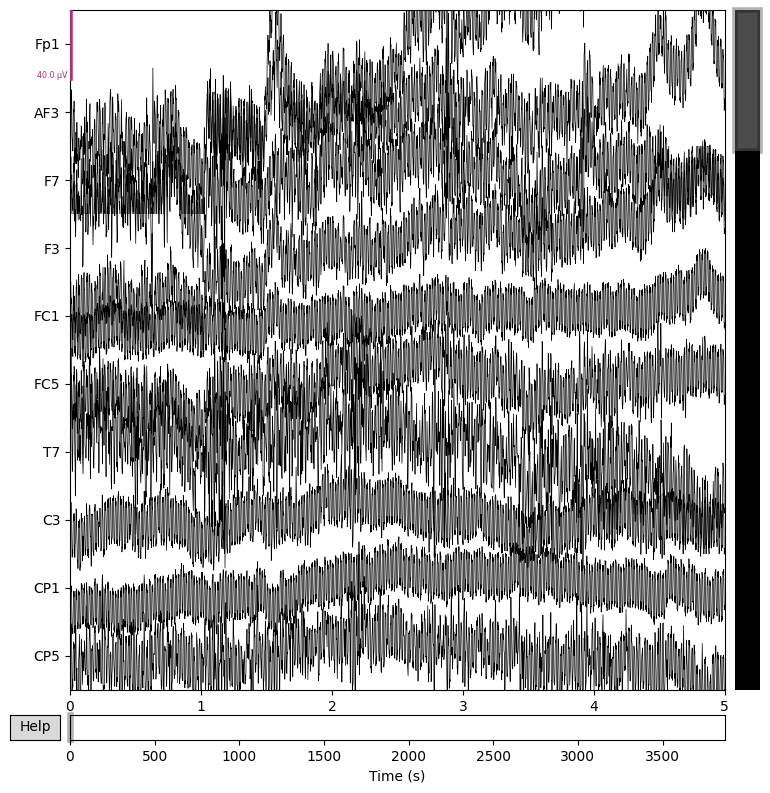

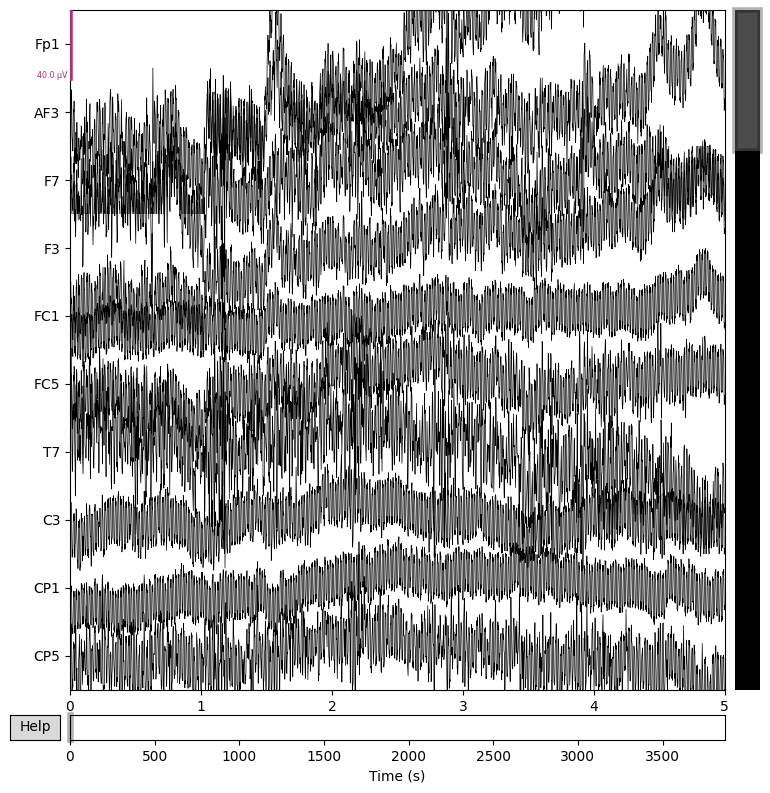

In [4]:
import mne

file_path = '/kaggle/input/deap-datasetraw-data/s01.bdf'  # example
raw = mne.io.read_raw_bdf(file_path, preload=True)

print(raw.info)  # info about channels, sampling rate
print(raw.ch_names)  # list of EEG channel names

# Plot first 5 seconds
raw.plot(start=0, duration=5, n_channels=10)


In [5]:
raw.filter(0.5, 50)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 3381 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done  47 out of  47 | elapsed:    3.2s finished


<RawEDF | s01.bdf, 48 x 1980928 (3869.0 s), ~725.5 MiB, data loaded>

In [6]:
# -------------------
# 1️⃣ Install and import libraries
# -------------------
!pip install mne --quiet

import os
import mne
import numpy as np
from scipy.signal import welch, butter, filtfilt

# -------------------
# 2️⃣ Load .bdf file
# -------------------
DATA_DIR = '/kaggle/input/deap-datasetraw-data'
file_path = os.path.join(DATA_DIR, 's01.bdf')  # change for other subjects
raw = mne.io.read_raw_bdf(file_path, preload=True)

print("Channels:", raw.ch_names)
print("Sampling Rate:", raw.info['sfreq'])

# -------------------
# 3️⃣ Bandpass Filter 0.5-50 Hz
# -------------------
def bandpass_filter(sig, sf, low=0.5, high=50, order=4):
    nyq = 0.5 * sf
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)

data = raw.get_data()  # channels x samples
sfreq = raw.info['sfreq']

filtered_data = np.zeros_like(data)
for ch in range(data.shape[0]):
    filtered_data[ch] = bandpass_filter(data[ch], sfreq)

# -------------------
# 4️⃣ Segment into 5-second windows
# -------------------
window_sec = 5
win_len = int(window_sec * sfreq)

segments = []
for start in range(0, data.shape[1] - win_len + 1, win_len):
    seg = filtered_data[:, start:start+win_len]
    segments.append(seg)

segments = np.array(segments)
print("Segments shape (windows x channels x samples):", segments.shape)

# -------------------
# 5️⃣ Feature extraction
# -------------------
bands = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,50)}

def bandpower(sig, sf, band):
    f, Pxx = welch(sig, fs=sf, nperseg=128)
    idx_band = (f >= band[0]) & (f <= band[1])
    return np.trapz(Pxx[idx_band], dx=f[1]-f[0])

def extract_features(seg):
    feats = []
    for ch in range(seg.shape[0]):
        s = seg[ch]
        # Time domain
        feats.append(np.mean(s))
        feats.append(np.std(s))
        feats.append(np.var(s))
        # Frequency domain
        for b in bands:
            feats.append(bandpower(s, sfreq, bands[b]))
    return np.array(feats)

X = np.array([extract_features(seg) for seg in segments])
print("Feature matrix shape (samples x features):", X.shape)


Extracting EDF parameters from /kaggle/input/deap-datasetraw-data/s01.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1980927  =      0.000 ...  3868.998 secs...
Channels: ['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Sampling Rate: 512.0
Segments shape (windows x channels x samples): (773, 48, 2560)
Feature matrix shape (samples x features): (773, 384)


Extracting EDF parameters from /kaggle/input/deap-datasetraw-data/s01.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1980927  =      0.000 ...  3868.998 secs...
Channels: ['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Sampling Rate: 512.0
Segments shape (windows x channels x samples): (773, 48, 2560)
Feature matrix shape (samples x features): (773, 384)
Labels distribution: (array([0, 1, 2]), array([255, 255, 263]))
Train shape: (541, 384) (541,)
Test shape: (232, 384) (232,)

### SVM Results:
Accuracy: 0.34051724137931033
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00  

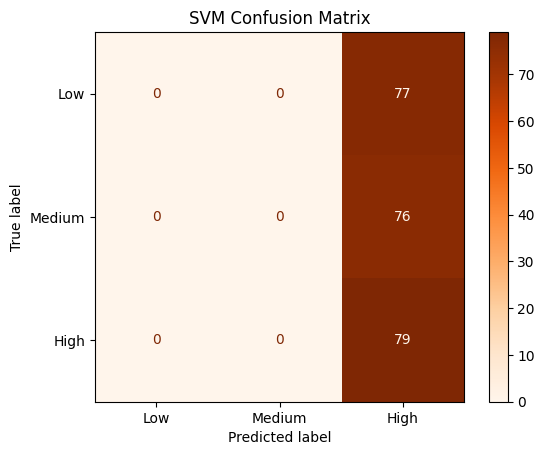


### RandomForest Results:
Accuracy: 0.9525862068965517
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        77
           1       0.92      0.93      0.93        76
           2       0.99      0.95      0.97        79

    accuracy                           0.95       232
   macro avg       0.95      0.95      0.95       232
weighted avg       0.95      0.95      0.95       232



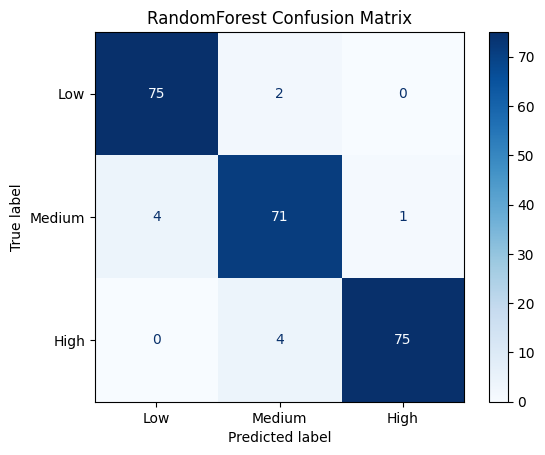


### KNN Results:
Accuracy: 0.9655172413793104
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        77
           1       0.96      0.93      0.95        76
           2       0.97      0.99      0.98        79

    accuracy                           0.97       232
   macro avg       0.97      0.97      0.97       232
weighted avg       0.97      0.97      0.97       232



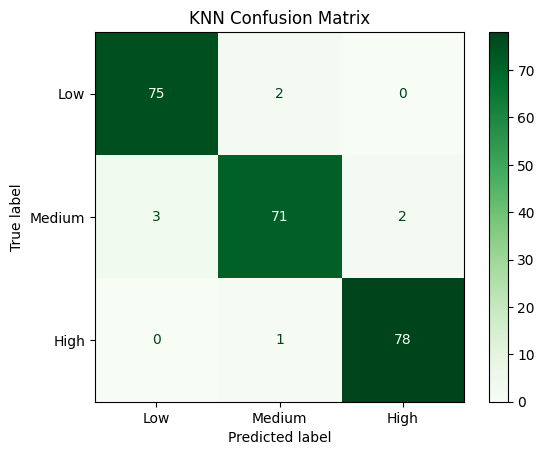

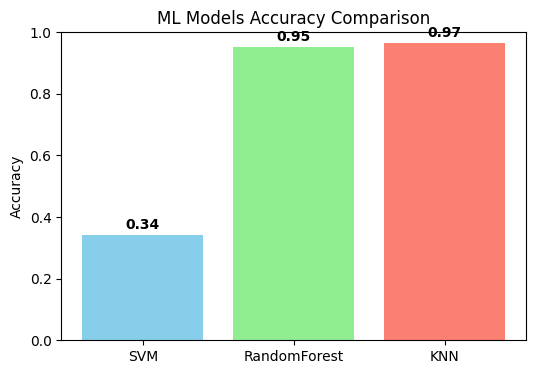

In [7]:
# -------------------
# 1️⃣ Install and import libraries
# -------------------
!pip install mne --quiet

import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# -------------------
# 2️⃣ Load first subject .bdf file
# -------------------
DATA_DIR = '/kaggle/input/deap-datasetraw-data'
file_path = os.path.join(DATA_DIR, 's01.bdf')
raw = mne.io.read_raw_bdf(file_path, preload=True)

print("Channels:", raw.ch_names)
sfreq = raw.info['sfreq']
print("Sampling Rate:", sfreq)

# -------------------
# 3️⃣ Bandpass Filter 0.5-50 Hz
# -------------------
def bandpass_filter(sig, sf, low=0.5, high=50, order=4):
    nyq = 0.5 * sf
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)

data = raw.get_data()  # channels x samples
filtered_data = np.zeros_like(data)
for ch in range(data.shape[0]):
    filtered_data[ch] = bandpass_filter(data[ch], sfreq)

# -------------------
# 4️⃣ Segment into 5-second windows
# -------------------
window_sec = 5
win_len = int(window_sec * sfreq)

segments = []
for start in range(0, data.shape[1] - win_len + 1, win_len):
    seg = filtered_data[:, start:start+win_len]
    segments.append(seg)

segments = np.array(segments)
print("Segments shape (windows x channels x samples):", segments.shape)

# -------------------
# 5️⃣ Feature extraction
# -------------------
bands = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,50)}

def bandpower(sig, sf, band):
    f, Pxx = welch(sig, fs=sf, nperseg=128)
    idx_band = (f >= band[0]) & (f <= band[1])
    return np.trapz(Pxx[idx_band], dx=f[1]-f[0])

def extract_features(seg):
    feats = []
    for ch in range(seg.shape[0]):
        s = seg[ch]
        # Time domain
        feats.append(np.mean(s))
        feats.append(np.std(s))
        feats.append(np.var(s))
        # Frequency domain
        for b in bands:
            feats.append(bandpower(s, sfreq, bands[b]))
    return np.array(feats)

X = np.array([extract_features(seg) for seg in segments])
print("Feature matrix shape (samples x features):", X.shape)

# -------------------
# 6️⃣ Synthetic labels (Low/Medium/High stress)
# -------------------
total_power = X.sum(axis=1)
y = np.digitize(total_power, bins=np.percentile(total_power, [33, 66]))  # 0=Low,1=Medium,2=High
print("Labels distribution:", np.unique(y, return_counts=True))

# -------------------
# 7️⃣ Train/Test Split
# -------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# -------------------
# 8️⃣ Train ML Models and Plot Confusion Matrices
# -------------------
models = {
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Different colormaps for each model
cmaps = {
    "SVM": plt.cm.Oranges,
    "RandomForest": plt.cm.Blues,
    "KNN": plt.cm.Greens
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n### {name} Results:")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion matrix plot with custom colors
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low","Medium","High"])
    disp.plot(cmap=cmaps[name])
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# -------------------
# 9️⃣ Accuracy Comparison Plot
# -------------------
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values(), color=['skyblue','lightgreen','salmon'])
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("ML Models Accuracy Comparison")
for i, v in enumerate(results.values()):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()
